In [1]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
# Statistics
models = ['NADE', 'Transformer', 'DecoderTransformer', 'MOE']
colors = ['red', 'blue', 'cyan', 'purple']

In [3]:
def graph_plot_means(models, x, colors, central_points_1, errors_1, er_label1, central_points_2, errors_2, er_label2, y_ticks, y_label, title):
    
    null1_pos = [0.1 for _ in range(len(models)*2)]
    null1_neg = [-0.1 for _ in range(len(models)*2)]
    null2_pos = [0.5 for _ in range(len(models)*2)]
    null2_neg = [-0.5 for _ in range(len(models)*2)]
    
    fig, ax = plt.subplots(figsize=(10,7))

    for i, m in enumerate(models):
        ax.errorbar(i*2, central_points_1[i], yerr=errors_1[i], fmt='o', color=colors[i], capsize=5, 
                markersize=10, elinewidth=2, label=m+' '+er_label1)
        ax.errorbar((i*2)+1, central_points_2[i], yerr=errors_2[i], fmt='*', color=colors[i], capsize=5, 
                markersize=15, elinewidth=2, label=m+' '+er_label2)


    ax.plot(x, null1_pos, 'y--', linewidth=3)
    ax.plot(x, null1_neg, 'y--', linewidth=3)
    ax.plot(x, null2_pos, 'y--', linewidth=3, alpha=0.5)
    ax.plot(x, null2_neg, 'y--', linewidth=3, alpha=0.5)

    ax.set_xticks([])
    ax.set_yticks(y_ticks)
    # Adjust y-tick font size
    ax.tick_params(axis='y', labelsize=14)
    ax.set_ylabel(y_label, fontsize=16, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.legend(loc='upper left', ncol=2, fontsize=12)

    # Adjust margins
    ax.margins(y=0.35)
    fig.tight_layout()
    plt.show()

In [4]:
def graph_plot_var(models, x, colors, central_points_1, errors_1, er_label1, central_points_2, errors_2,er_label2, y_ticks, y_label, title):

    fig, ax = plt.subplots(figsize=(10,7))

    for i, m in enumerate(models):
        ax.errorbar(i*2, central_points_1[i], yerr=errors_1[i], fmt='o', color=colors[i], capsize=5, 
                markersize=10, elinewidth=2, label=m+' '+er_label1)
        ax.errorbar((i*2)+1, central_points_2[i], yerr=errors_2[i], fmt='*', color=colors[i], capsize=5, 
                markersize=15, elinewidth=2, label=m+' '+er_label2)

    nullvar_pos = [1.0 for _ in range(len(models)*2)]
    ax.plot(x, nullvar_pos, 'y--', linewidth=3)

    ax.set_xticks([])
    ax.set_yticks(y_ticks)
    # Adjust y-tick font size
    ax.tick_params(axis='y', labelsize=14)
    ax.set_ylabel(y_label, fontsize=16, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.legend(loc='upper left', ncol=2, fontsize=12)

    # Adjust margins
    ax.margins(y=0.35)
    fig.tight_layout()
    plt.show()

In [5]:
cis_perm = [(-0.09800717948369757, 0.08824550699028373), 
       (-0.0730606755527336, -0.004635752881748424), 
       (-0.4987478959606886, -0.40051865730690805), 
       (0.033068241451102605, 0.11016413192687854)]

cis_null = [(-0.1352584558025073, 0.08598271568551102),
            (-0.339874591942137, 0.31369153313703224),
            (-0.38854888798385684, 0.2817820487631419),
            (-0.4135138574446752, 0.23650790164887953)]

central_points_perm = [(ci[0] + ci[1]) / 2 for ci in cis_perm]
errors_perm = [(ci[1] - ci[0]) / 2 for ci in cis_perm]
central_points_null = [(ci[0] + ci[1]) / 2 for ci in cis_null]
errors_null = [(ci[1] - ci[0]) / 2 for ci in cis_null]
x = [i for i in range(len(models)*2)]
er_label1 = 'Permutations'
er_label2 = 'Random'
y_ticks = [-0.5, -0.1, 0.0, 0.1, 0.5]
y_label = "Mean of Difference Between Log Probabilities"
title = "0.95 Confidence Intervals on Mean for Log Differences on Permutations"

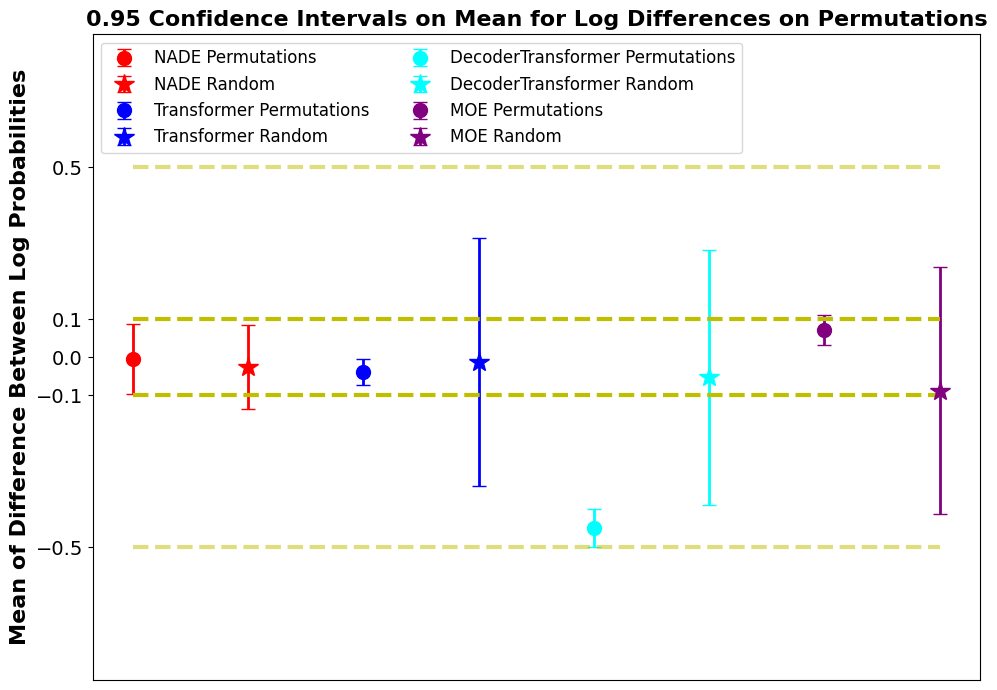

In [6]:
graph_plot_means(models=models, x=x, colors=colors, central_points_1=central_points_perm, errors_1=errors_perm, er_label1=er_label1, 
                 central_points_2=central_points_null, errors_2=errors_null, er_label2=er_label2, y_ticks=y_ticks, y_label=y_label, title=title)

In [7]:
cis_var_models = [(1.836336344841362, 1.968225408481784),
                  (0.6746274363738786, 0.7230804232896146),
                  (0.9684795665550395, 1.03803755550769),
                  (0.7601178184259567, 0.8147108822784614)]
cis_var_null = [(2.18130117675099, 2.337966250950287),
                (6.4437579503459785, 6.906560532663803),
                (6.60904862916986, 7.083722692940311),
                (6.408812692900189, 6.869105442367323)]

central_points_var_model = [(ci[0] + ci[1]) / 2 for ci in cis_var_models]
errors_var_model = [(ci[1] - ci[0]) / 2 for ci in cis_var_models]
central_points_var_null = [(ci[0] + ci[1]) / 2 for ci in cis_var_null]
errors_var_null = [(ci[1] - ci[0]) / 2 for ci in cis_var_null]
y_ticks= [i for i in range(10)]
er_label1 = 'Permutations'
er_label2 = 'Random'
y_label = "Variance of Difference Between Log Probabilities"
title = "0.95 Confidence Intervals on Variance for Log Differences on Permutations"

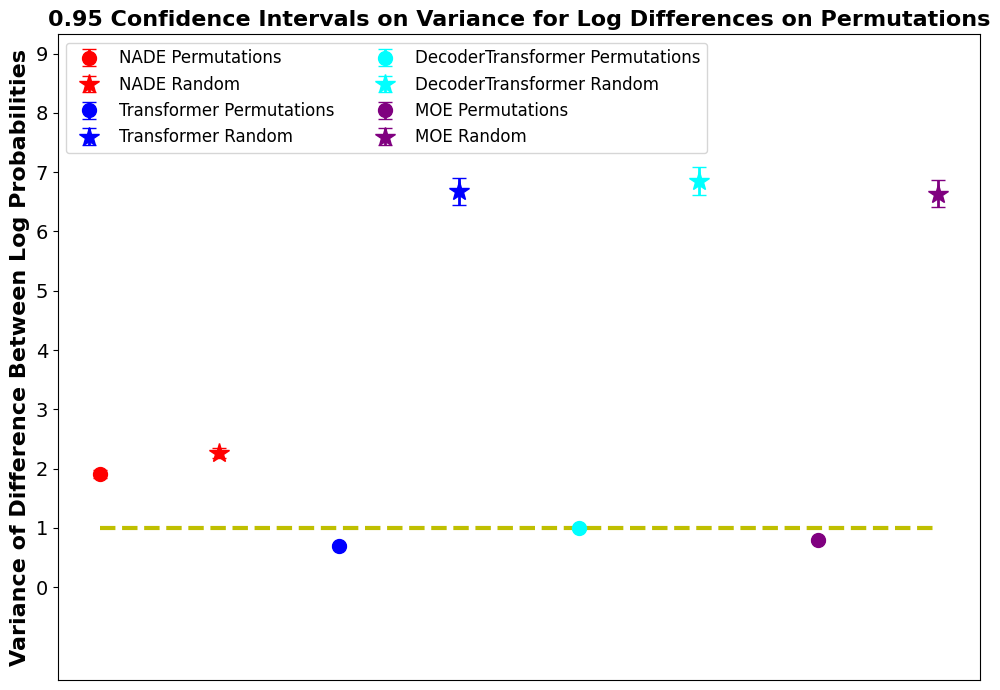

In [8]:
graph_plot_var(models=models, x=x, colors=colors, central_points_1=central_points_var_model, errors_1=errors_var_model, er_label1=er_label1, 
               central_points_2=central_points_var_null, errors_2=errors_var_null, er_label2=er_label2, y_ticks=y_ticks, y_label=y_label, title=title)

In [9]:
cis_mean_notrain_model = [(-0.09942722179502403, -0.04538656262603816),
                          (-0.14979505719982333, -0.010868830465853255),
                          (-0.15187910830237655, 0.047491481224736815),
                          (-0.5225573895550596, -0.1528708783567567)]
cis_mean_notrain_null =[(-0.032401095445650833, 0.022386867951718584),
                        (-0.19739121516646635, 0.4237180339250812),
                        (-0.39299567395006746, 0.26853475297883084),
                        (-0.2136241081557821, 0.813343086275315)]

central_points_mean_notrain_model = [(ci[0] + ci[1]) / 2 for ci in cis_mean_notrain_model]
errors_mean_notrain_model = [(ci[1] - ci[0]) / 2 for ci in cis_mean_notrain_model]
central_points_mean_notrain_null = [(ci[0] + ci[1]) / 2 for ci in cis_mean_notrain_null]
errors_mean_notrain_null = [(ci[1] - ci[0]) / 2 for ci in cis_mean_notrain_null]
x = [i for i in range(len(models)*2)]
er_label1 = 'Trained Model'
er_label2 = 'No Training'
y_ticks = [-0.5, -0.1, 0.0, 0.1, 0.5]
y_label = "Mean of Difference Between Log Probabilities"
title = "0.95 Confidence Intervals on Mean for Log Differences on Permutations"

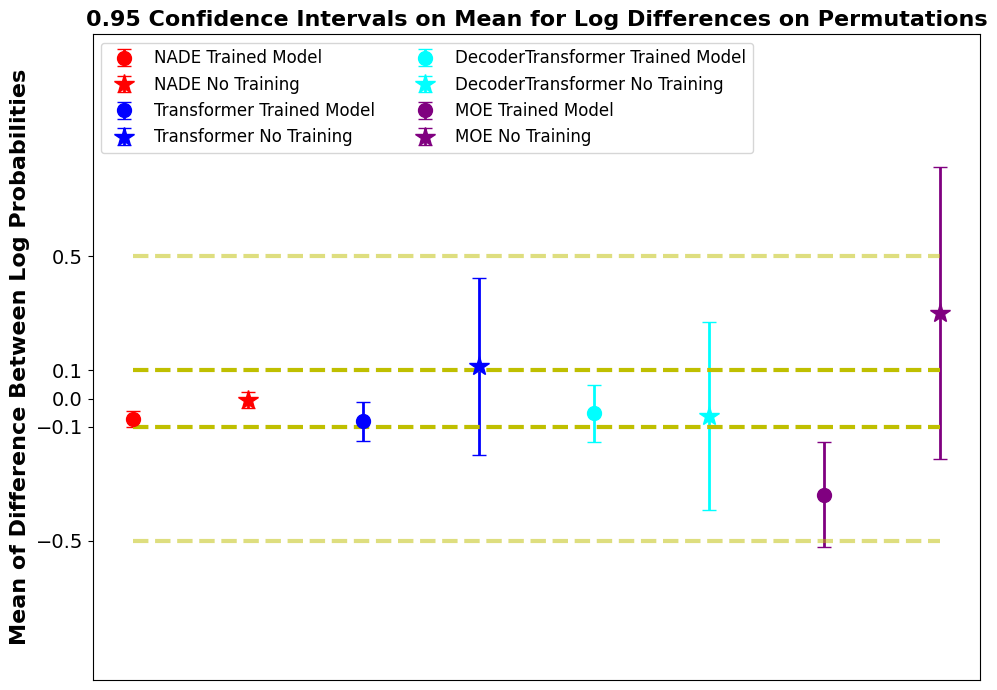

In [10]:
graph_plot_means(models=models, x=x, colors=colors, central_points_1=central_points_mean_notrain_model, errors_1=errors_mean_notrain_model, er_label1=er_label1, 
                 central_points_2=central_points_mean_notrain_null, errors_2=errors_mean_notrain_null, er_label2=er_label2, y_ticks=y_ticks, y_label=y_label, title=title)

In [11]:
cis_var_models_notrain = [(0.5328074907797709, 0.5710747075981677),
                          (1.3697267096273509, 1.4681030085463997),
                          (1.9656707592898588, 2.1068488591496055),
                          (3.644880455487453, 3.906662493242113)]

central_points_var_model_notrain = [(ci[0] + ci[1]) / 2 for ci in cis_var_models_notrain]
errors_var_model_notrain = [(ci[1] - ci[0]) / 2 for ci in cis_var_models_notrain]
x = [i for i in range(len(models)*2)]
er_label1 = 'Trained Model'
er_label2 = 'No Training'
y_ticks= [i for i in range(5)]
y_label = "Variance of Difference Between Log Probabilities"
title = "0.95 Confidence Intervals on Variance for Log Differences on Trained/No Trained Models"

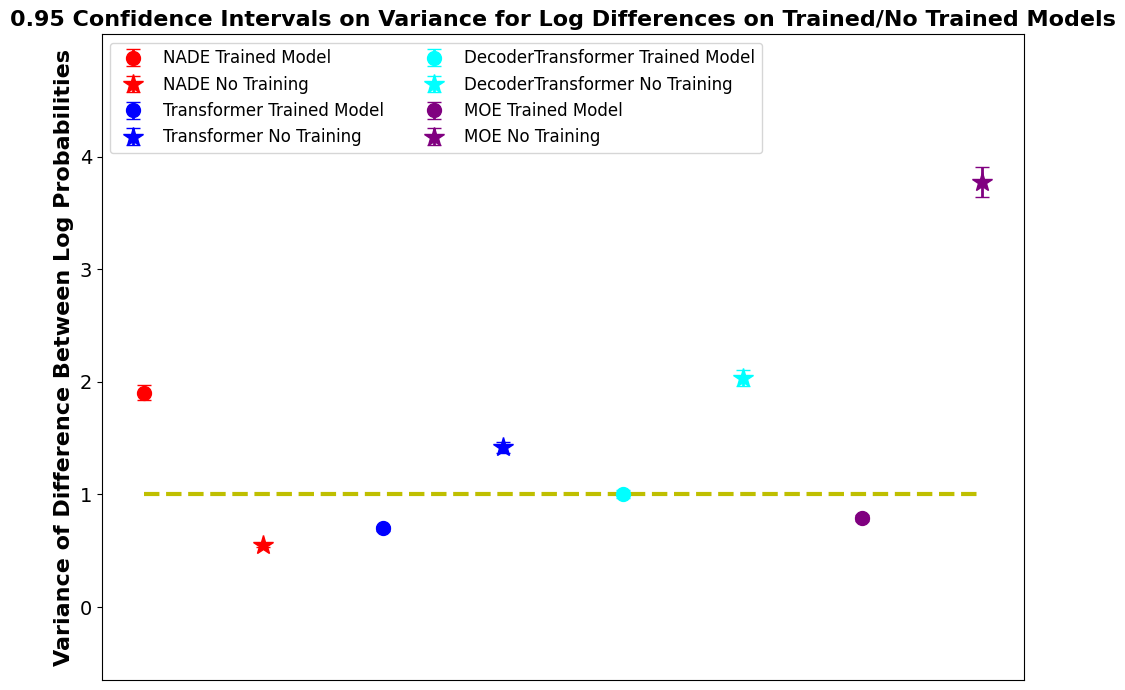

In [12]:
graph_plot_var(models=models, x=x, colors=colors, central_points_1=central_points_var_model, errors_1=errors_var_model, er_label1=er_label1, 
               central_points_2=central_points_var_model_notrain, errors_2=errors_var_model_notrain, er_label2=er_label2, y_ticks=y_ticks, y_label=y_label, title=title)

In [13]:
models = ['Transformer', 'DecoderTransformer', 'MOE']
colors = ['blue', 'cyan', 'purple']
cis_diff_train_model = [(9.56646433681422, 9.92090012299316),
                        (9.19922816787868, 9.556625840970291),
                        (9.690797949625797, 10.036685478686554)]
cis_diff_train_null =[(9.428971923435832, 10.00323437792683),
                      (9.103250048699135, 9.673966496813978),
                      (9.618693076747183, 10.19206425126155)]

central_points_diff_train_model = [(ci[0] + ci[1]) / 2 for ci in cis_diff_train_model]
errors_diff_train_model = [(ci[1] - ci[0]) / 2 for ci in cis_diff_train_model]
central_points_diff_train_null = [(ci[0] + ci[1]) / 2 for ci in cis_diff_train_null]
errors_diff_train_null = [(ci[1] - ci[0]) / 2 for ci in cis_diff_train_null]
x = [i for i in range(len(models)*2)]
er_label1 = 'Original Sequence'
er_label2 = 'Random Sequence'
y_ticks = [i - 1.0 for i in range(12)]
y_label = "Mean of Difference Between Log Probabilities"
title = "0.95 Confidence Intervals on Mean for Log Differences between Interventional and Model Distribution"

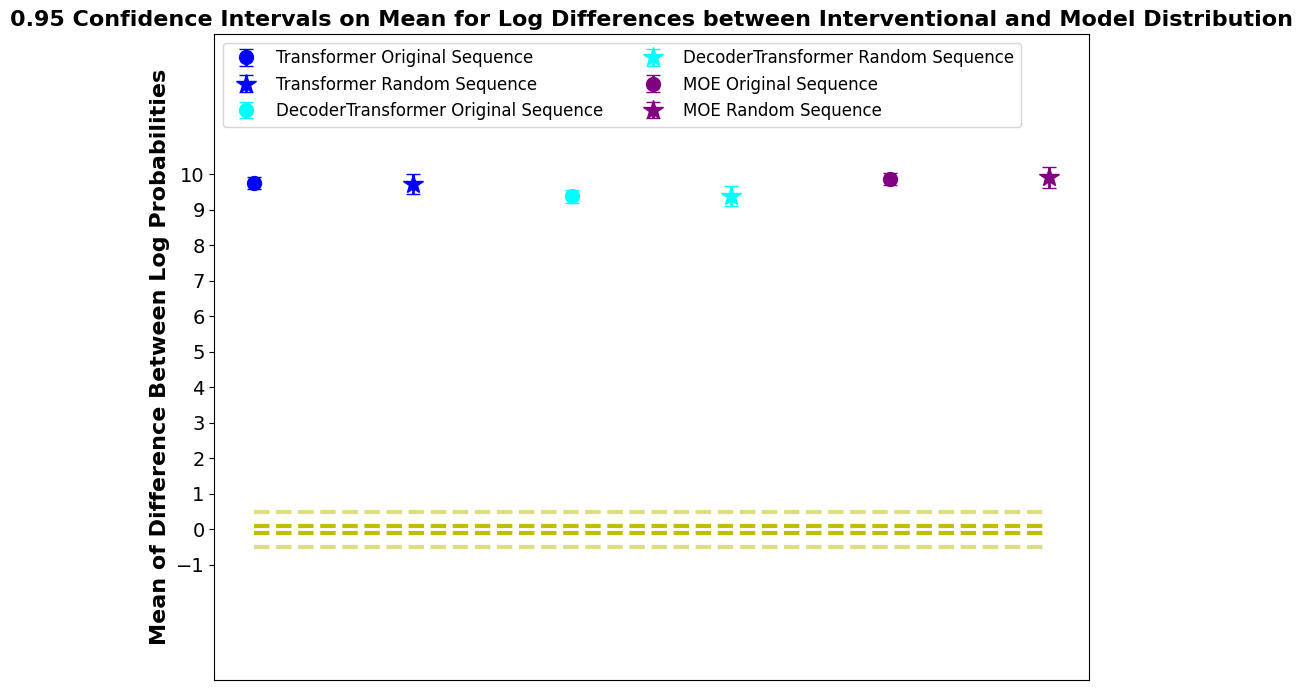

In [14]:
graph_plot_means(models=models, x=x, colors=colors, central_points_1=central_points_diff_train_model, errors_1=errors_diff_train_model, er_label1=er_label1, 
                 central_points_2=central_points_diff_train_null, errors_2=errors_diff_train_null, er_label2=er_label2, y_ticks=y_ticks, y_label=y_label, title=title)

In [15]:
cis_diff_train_model = [(13.703671808870705, 13.85740588975127),
                        (13.469991916089917, 13.61988208829639),
                        (13.725442166445317, 13.88619491700983)]
cis_diff_train_null =[(13.46864828921747, 14.118612468209616),
                      (13.266798550370218, 13.929842293236803),
                      (13.574295012059634, 14.214348027191305)]

central_points_diff_train_model = [(ci[0] + ci[1]) / 2 for ci in cis_diff_train_model]
errors_diff_train_model = [(ci[1] - ci[0]) / 2 for ci in cis_diff_train_model]
central_points_diff_train_null = [(ci[0] + ci[1]) / 2 for ci in cis_diff_train_null]
errors_diff_train_null = [(ci[1] - ci[0]) / 2 for ci in cis_diff_train_null]
x = [i for i in range(len(models)*2)]
er_label1 = 'Original Sequence'
er_label2 = 'Random Sequence'
y_ticks = [i - 1.0 for i in range(17)]
y_label = "Mean of Difference Between Log Probabilities"
title = "0.95 Confidence Intervals on Mean for Log Differences between Normal and Model Distributions"


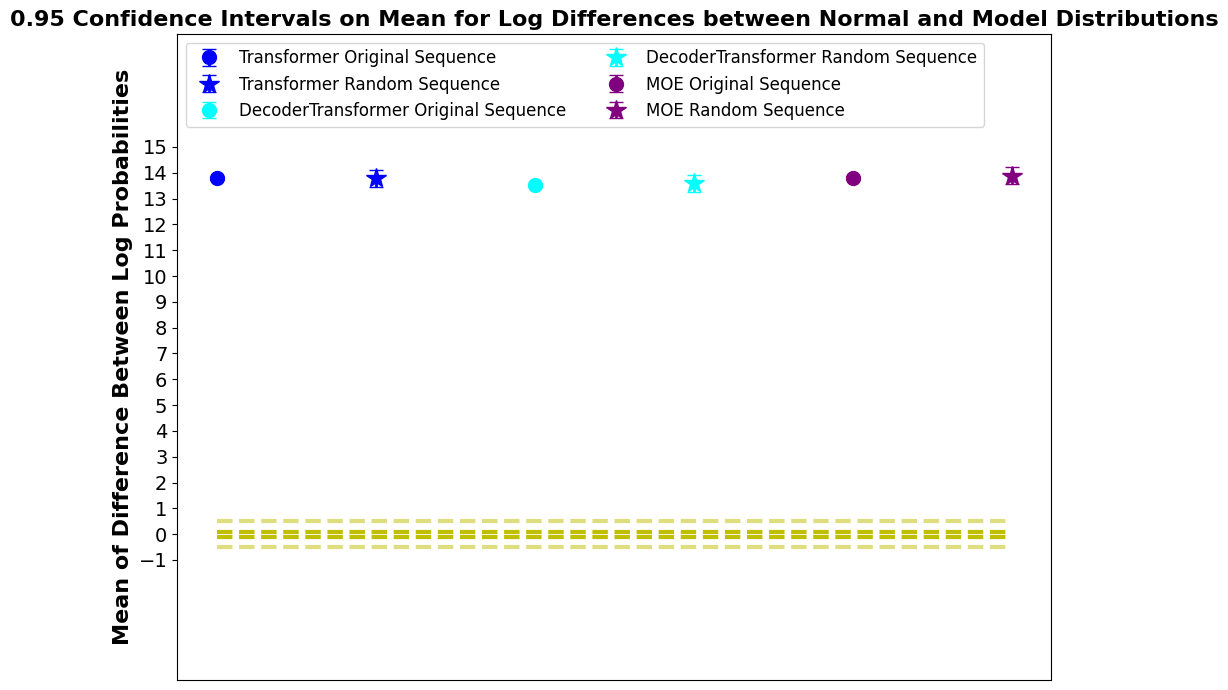

In [16]:
graph_plot_means(models=models, x=x, colors=colors, central_points_1=central_points_diff_train_model, errors_1=errors_diff_train_model, er_label1=er_label1, 
                 central_points_2=central_points_diff_train_null, errors_2=errors_diff_train_null, er_label2=er_label2, y_ticks=y_ticks, y_label=y_label, title=title)